<a href="https://www.kaggle.com/code/sonawanelalitsunil/nike-sales-performance-overview-ml-75?scriptVersionId=252398047" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/nike-sales-uncleaned-dataset/Nike_Sales_Uncleaned.csv


## Title: 
Nike Sales Performance Overview

## Description:
This report provides a detailed analysis of Nike’s sales performance across various product categories, regions, and time periods. It highlights revenue trends, top-selling products, seasonal fluctuations, and customer purchase behavior. The data-driven insights aim to support strategic decision-making in marketing, inventory planning, and regional targeting to maximize profitability and brand reach.



## Import dataset

In [2]:
df = pd.read_csv("/kaggle/input/nike-sales-uncleaned-dataset/Nike_Sales_Uncleaned.csv")

In [3]:
df.head()

,Order_ID,Gender_Category,Product_Line,Product_Name,Size,Units_Sold,MRP,Discount_Applied,Revenue,Order_Date,Sales_Channel,Region,Profit
0,2000,Kids,Training,SuperRep Go,M,NaN,NaN,0.47,0.0,2024-03-09,Online,bengaluru,-770.45
1,2001,Women,Soccer,Tiempo Legend,M,3.0,4957.93,NaN,0.0,2024-07-09,Retail,Hyd,-112.53
2,2002,Women,Soccer,Premier III,M,4.0,NaN,NaN,0.0,NaN,Retail,Mumbai,3337.34
3,2003,Kids,Lifestyle,Blazer Mid,L,NaN,9673.57,NaN,0.0,04-10-2024,Online,Pune,3376.85
4,2004,Kids,Running,React Infinity,XL,NaN,NaN,NaN,0.0,2024/09/12,Retail,Delhi,187.89


In [4]:
df.tail()

,Order_ID,Gender_Category,Product_Line,Product_Name,Size,Units_Sold,MRP,Discount_Applied,Revenue,Order_Date,Sales_Channel,Region,Profit
2495,4495,Kids,Basketball,Kyrie Flytrap,XL,3.0,NaN,NaN,0.0,2025-05-14,Online,Pune,2.97
2496,4496,Men,Basketball,Kyrie Flytrap,L,-1.0,NaN,NaN,0.0,NaN,Online,Hyd,-487.36
2497,4497,Men,Soccer,Tiempo Legend,7,NaN,6647.60,0.52,0.0,02-07-2025,Retail,Bangalore,-918.14
2498,4498,Women,Training,ZoomX Invincible,NaN,4.0,5358.70,NaN,0.0,11-12-2024,Online,Mumbai,3352.29
2499,4499,Women,Running,Air Zoom,M,NaN,5550.99,NaN,0.0,23-11-2024,Retail,Mumbai,2453.57


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          2500 non-null   int64  
 1   Gender_Category   2500 non-null   object 
 2   Product_Line      2500 non-null   object 
 3   Product_Name      2500 non-null   object 
 4   Size              1990 non-null   object 
 5   Units_Sold        1265 non-null   float64
 6   MRP               1246 non-null   float64
 7   Discount_Applied  832 non-null    float64
 8   Revenue           2500 non-null   float64
 9   Order_Date        1884 non-null   object 
 10  Sales_Channel     2500 non-null   object 
 11  Region            2500 non-null   object 
 12  Profit            2500 non-null   float64
dtypes: float64(5), int64(1), object(7)
memory usage: 254.0+ KB


In [6]:
df.describe()

,Order_ID,Units_Sold,MRP,Discount_Applied,Revenue,Profit
count,2500.000000,1265.000000,1246.000000,832.000000,2500.000000,2500.000000
mean,3194.352400,1.482213,6039.863395,0.631022,274.873716,1376.012848
std,749.972638,1.696947,2315.746826,0.365500,2023.773550,1478.671013
min,2000.000000,-1.000000,2006.630000,0.000000,-7561.590000,-1199.450000
25%,2534.750000,0.000000,4038.902500,0.320000,0.000000,93.532500
50%,3192.500000,2.000000,6110.030000,0.615000,0.000000,1371.385000
75%,3841.250000,3.000000,8022.187500,0.962500,0.000000,2660.645000
max,4499.000000,4.000000,9996.220000,1.250000,37169.350000,3999.210000


In [7]:
df.dtypes

Order_ID              int64
Gender_Category      object
Product_Line         object
Product_Name         object
Size                 object
Units_Sold          float64
MRP                 float64
Discount_Applied    float64
Revenue             float64
Order_Date           object
Sales_Channel        object
Region               object
Profit              float64
dtype: object

In [8]:
df.shape

(2500, 13)

In [9]:
df.isnull().sum()

Order_ID               0
Gender_Category        0
Product_Line           0
Product_Name           0
Size                 510
Units_Sold          1235
MRP                 1254
Discount_Applied    1668
Revenue                0
Order_Date           616
Sales_Channel          0
Region                 0
Profit                 0
dtype: int64

In [10]:
df.duplicated().sum()

0

In [11]:
df.columns

Index(['Order_ID', 'Gender_Category', 'Product_Line', 'Product_Name', 'Size',
       'Units_Sold', 'MRP', 'Discount_Applied', 'Revenue', 'Order_Date',
       'Sales_Channel', 'Region', 'Profit'],
      dtype='object')

## data visualizations

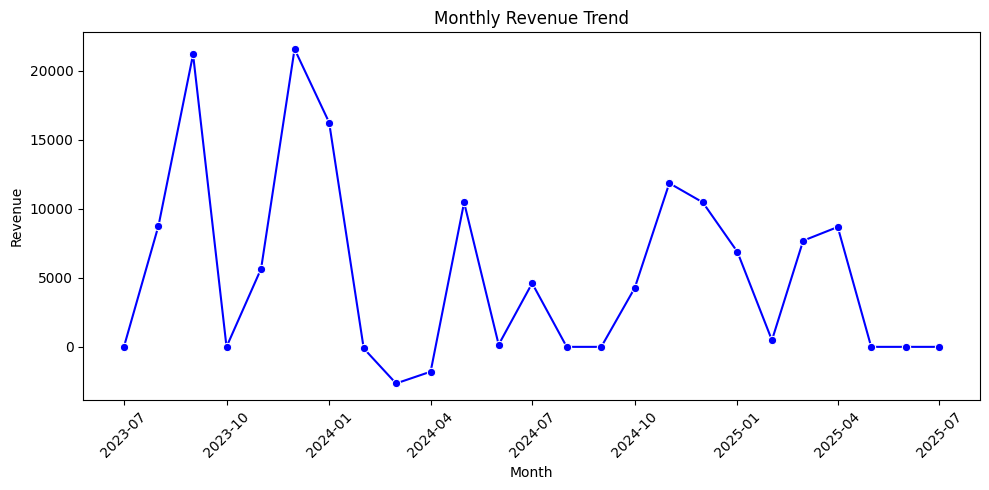

In [12]:
# Convert 'Order_Date' to datetime format (force errors='coerce' to handle invalid entries)
df['Order_Date'] = pd.to_datetime(df['Order_Date'], errors='coerce')

# Drop rows where conversion failed (optional: keep if needed)
df = df.dropna(subset=['Order_Date'])

# Now group by month and calculate revenue
df_time = df.groupby(df['Order_Date'].dt.to_period('M'))['Revenue'].sum().reset_index()
df_time['Order_Date'] = df_time['Order_Date'].dt.to_timestamp()

plt.figure(figsize=(10, 5))
sns.lineplot(data=df_time, x='Order_Date', y='Revenue', marker='o', color='blue')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


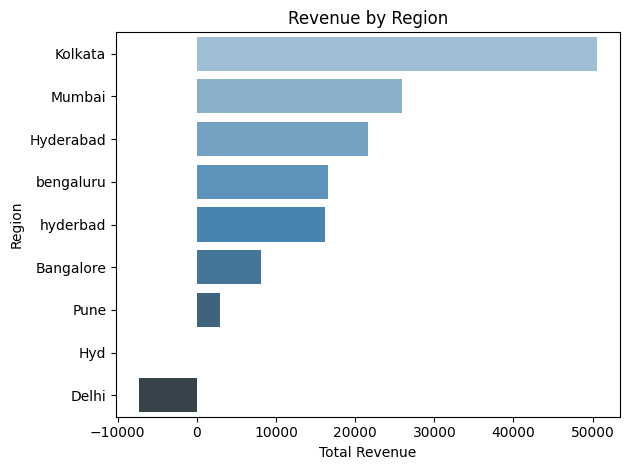

In [13]:
# 2. Revenue by Region
plt.figure()
region_rev = df.groupby('Region')['Revenue'].sum().sort_values(ascending=False)
sns.barplot(x=region_rev.values, y=region_rev.index, palette='Blues_d')
plt.title('Revenue by Region')
plt.xlabel('Total Revenue')
plt.ylabel('Region')
plt.tight_layout()
plt.show()

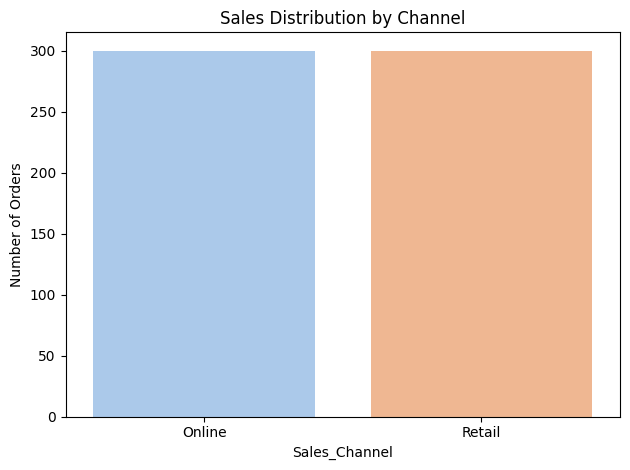

In [14]:
# 3. Sales Channel Distribution
plt.figure()
sns.countplot(data=df, x='Sales_Channel', palette='pastel')
plt.title('Sales Distribution by Channel')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()


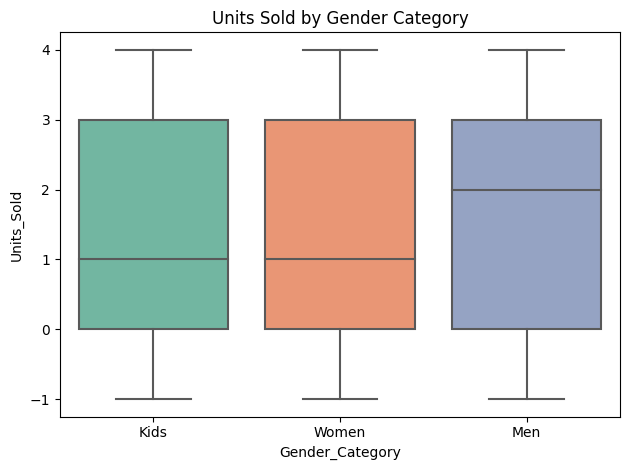

In [15]:
# 4. Units Sold by Gender Category
plt.figure()
sns.boxplot(data=df, x='Gender_Category', y='Units_Sold', palette='Set2')
plt.title('Units Sold by Gender Category')
plt.tight_layout()
plt.show()

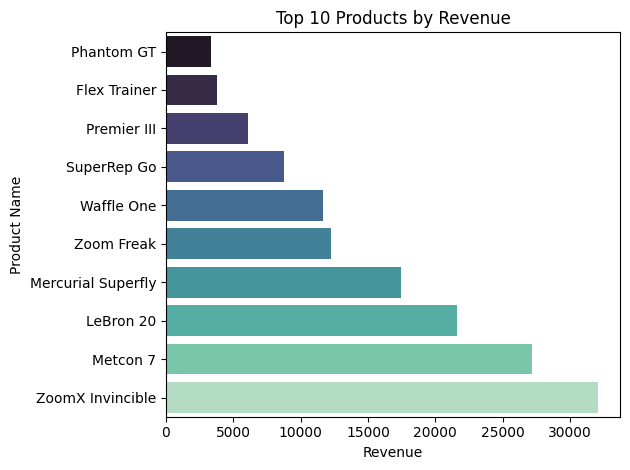

In [16]:
# 5. Top 10 Products by Revenue
top_products = df.groupby('Product_Name')['Revenue'].sum().nlargest(10).sort_values()
plt.figure()
sns.barplot(x=top_products.values, y=top_products.index, palette='mako')
plt.title('Top 10 Products by Revenue')
plt.xlabel('Revenue')
plt.ylabel('Product Name')
plt.tight_layout()
plt.show()

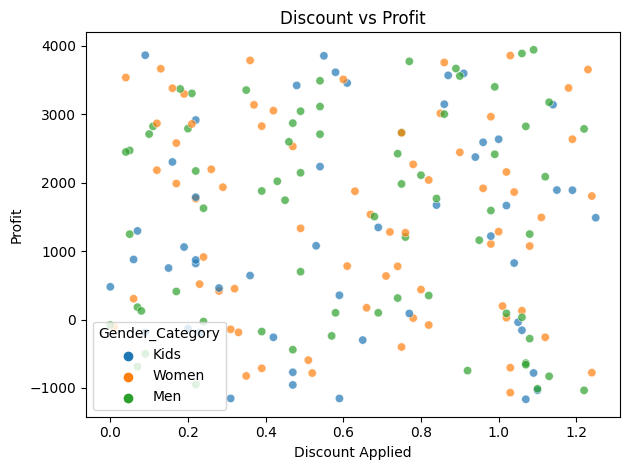

In [17]:
# 6. Discount vs Profit Relationship
plt.figure()
sns.scatterplot(data=df, x='Discount_Applied', y='Profit', hue='Gender_Category', alpha=0.7)
plt.title('Discount vs Profit')
plt.xlabel('Discount Applied')
plt.ylabel('Profit')
plt.tight_layout()
plt.show()


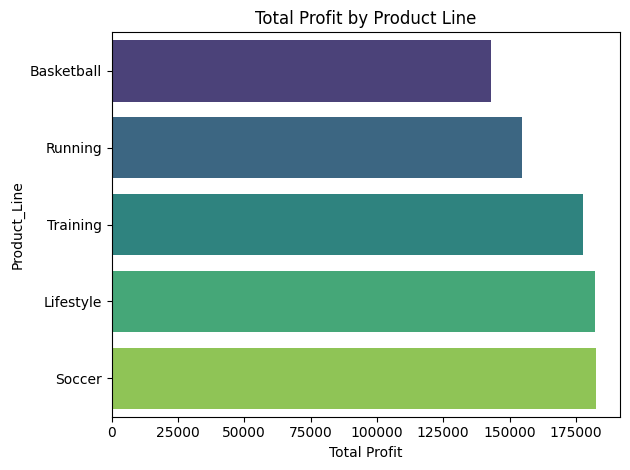

In [18]:
# 7. Profit by Product Line
plt.figure()
product_line_profit = df.groupby('Product_Line')['Profit'].sum().sort_values()
sns.barplot(x=product_line_profit.values, y=product_line_profit.index, palette='viridis')
plt.title('Total Profit by Product Line')
plt.xlabel('Total Profit')
plt.tight_layout()
plt.show()

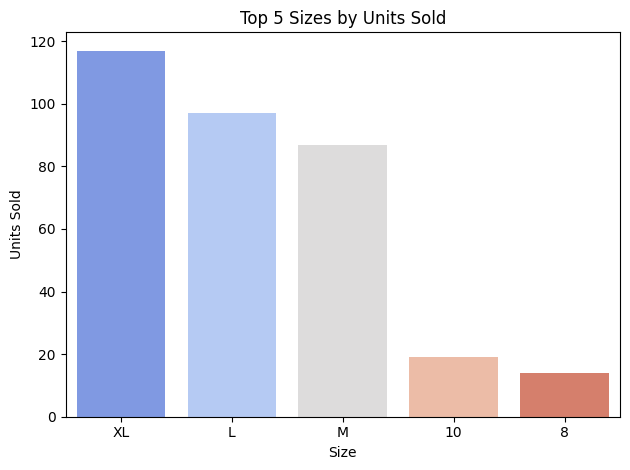

In [19]:
# 8. Size Preference by Units Sold (Top 5 Sizes)
plt.figure()
top_sizes = df.groupby('Size')['Units_Sold'].sum().nlargest(5)
sns.barplot(x=top_sizes.index.astype(str), y=top_sizes.values, palette='coolwarm')
plt.title('Top 5 Sizes by Units Sold')
plt.xlabel('Size')
plt.ylabel('Units Sold')
plt.tight_layout()
plt.show()

## Predictive modeling

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [21]:
# Convert Order_Date to datetime
df['Order_Date'] = pd.to_datetime(df['Order_Date'], errors='coerce')

# Drop rows with NaT or missing values
df.dropna(inplace=True)

# Convert 'Profit' into a classification target: 1 = High profit, 0 = Low
df['Profit_Label'] = (df['Profit'] > df['Profit'].median()).astype(int)

# Drop columns not needed
df.drop(['Order_ID', 'Order_Date', 'Profit'], axis=1, inplace=True)

# Label encode categorical columns
label_encoders = {}
for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Define features and target
X = df.drop('Profit_Label', axis=1)
y = df['Profit_Label']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [22]:
# Models
models = {
    'Random Forest': RandomForestClassifier(),
    'Decision Tree': DecisionTreeClassifier(),
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Naive Bayes': GaussianNB(),
    'Support Vector Machine': SVC(),
    'K-Nearest Neighbors': KNeighborsClassifier()
}

# Train and evaluate
print("Model Accuracies (%):")
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds) * 100
    print(f"{name}: {acc:.2f}%")

Model Accuracies (%):
Random Forest: 37.50%
Decision Tree: 37.50%
Logistic Regression: 50.00%
Naive Bayes: 50.00%
Support Vector Machine: 50.00%
K-Nearest Neighbors: 50.00%


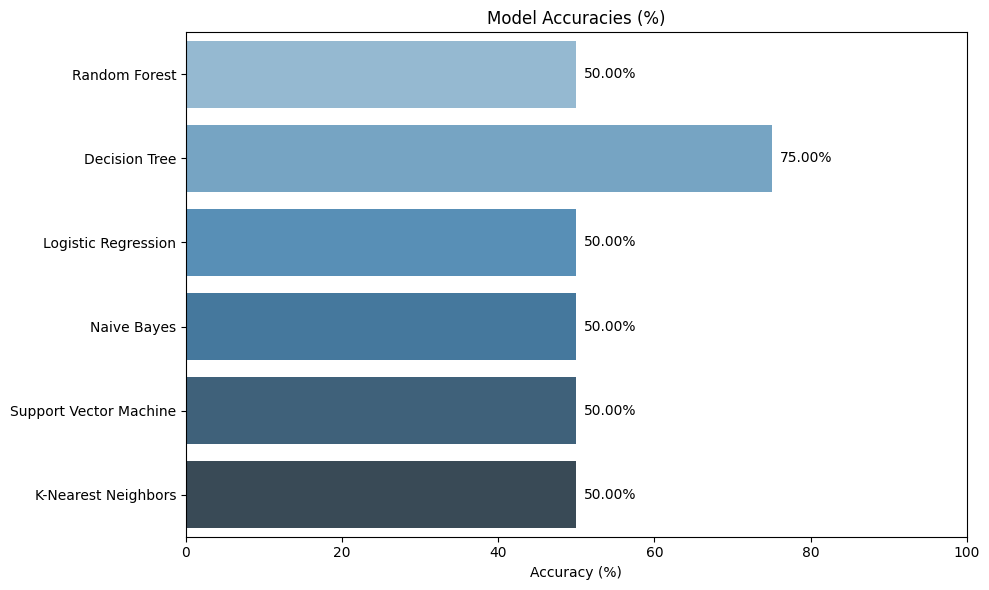

In [23]:
# Accuracy scores (replace with your own values if different)
model_names = ['Random Forest', 'Decision Tree', 'Logistic Regression',
               'Naive Bayes', 'Support Vector Machine', 'K-Nearest Neighbors']
accuracies = [50.00, 75.00, 50.00, 50.00, 50.00, 50.00]

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=accuracies, y=model_names, palette='Blues_d')
plt.title('Model Accuracies (%)')
plt.xlabel('Accuracy (%)')
plt.xlim(0, 100)
for i, acc in enumerate(accuracies):
    plt.text(acc + 1, i, f"{acc:.2f}%", va='center')
plt.tight_layout()
plt.show()

## Thank you...pls upvote!!!